<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 7 Day 2: Building CNNs & Transfer Learning
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 2 Learning Objectives:</b>
- <b>Pooling Mechanics:</b> Analyze how Max Pooling ($2 \times 2$) shrinks feature maps, reduces computational load, controls overfitting, and confers shift robustness.
- <b>Full CNN Architecture:</b> Build an end-to-end convolutional network combining feature extraction blocks (`Conv2D` + `MaxPooling2D`) and classification layers (`Flatten` + `Dense`).
- <b>Data Augmentation:</b> Apply computer vision data augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom`) as the standard first defense against overfitting.
- <b>Transfer Learning:</b> Reuse pre-trained models (e.g., `MobileNetV2` trained on ImageNet), freeze pre-trained feature extractors, and train custom dense heads.
- <b>Empirical Benchmarking:</b> Evaluate and compare a scratch CNN, an augmented CNN, and a transfer learning model in terms of test accuracy and training time.

</blockquote>


---
## <span style="color: #309c42ff">1. Dataset Acquisition & tf.data Pipeline Optimization</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Loading the <b>Melanoma Skin Cancer Dataset (Benign vs. Malignant)</b> at a standard spatial resolution of $224 \times 224 \times 3$. We utilize `tf.data` optimizations (`cache` and `prefetch`) to prevent GPU starvation during training.

</blockquote>

### Pipeline Specification:
- **`image_dataset_from_directory`:** Loads image batches dynamically with binary label mode and consistent random seeding.
- **`.cache()`:** Caches images in memory after the first epoch to eliminate repetitive disk reading.
- **`.prefetch(buffer_size=AUTOTUNE)`:** Overlaps data preprocessing and GPU model execution.


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

DATA_DIR = "../../Data/Image_dataset"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_perf = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_perf = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 11879 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


---
## <span style="color: #309c42ff">2. Step 1: Building and Training a Small CNN from Scratch</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

A typical CNN stacks convolution + pooling blocks to extract features, then flattens the result and feeds it into dense layers for the final classification.

</blockquote>

### Layer Mechanics & Concepts:
- **Convolution (`Conv2D`):** Slides small learnable filters across the image to compute local dot products and generate feature maps.
- **Max Pooling ($2 \times 2$):** Shrinks the feature map by keeping only the strongest signal in each small region, reducing computation, controlling overfitting, and making the network robust to small shifts.
- **Classification Head:** `Flatten` collapses spatial feature maps into a 1D vector, followed by `Dense(64, activation="relu")` and `Dense(1, activation="sigmoid")`.


In [ ]:
model_scratch = Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Rescaling(1.0 / 255.0),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="Scratch_CNN")

model_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_scratch.summary()

start_scratch = time.time()
history_scratch = model_scratch.fit(
    train_ds_perf,
    epochs=10,
    validation_data=test_ds_perf,
    verbose=1
)
scratch_train_time = time.time() - start_scratch

scratch_loss, scratch_acc = model_scratch.evaluate(test_ds_perf, verbose=0)
print(f"Scratch CNN Final Test Accuracy: {scratch_acc * 100:.2f}% | Training Time: {scratch_train_time:.2f}s")


Model: "Scratch_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,713 (12.47 MB)

 Trainable params: 3,267,713 (12.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.7869 - loss: 0.4449 - val_accuracy: 0.8095 - val_loss: 0.3867
Epoch 2/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8411 - loss: 0.3489 - val_accuracy: 0.7950 - val_loss: 0.4082
Epoch 3/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8634 - loss: 0.3177 - val_accuracy: 0.8695 - val_loss: 0.2996
Epoch 4/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8737 - loss: 0.3016 - val_accuracy: 0.8925 - val_loss: 0.2770
Epoch 5/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8771 - loss: 0.2826 - val_accuracy: 0.9005 - val_loss: 0.2600
Epoch 6/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8874 - loss: 0.2655 - val_accuracy: 0.9135 - val_loss: 0.2501
Epoch 7/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8965 - loss: 0.2506 - val_accuracy: 0.9205 - val_loss: 0.2411
Epoch 8/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9022 - loss: 0.2332 - 

---
## <span style="color: #309c42ff">3. Step 2: Combating Overfitting with Data Augmentation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Image datasets are often too small to train a strong CNN without overfitting. <b>Data augmentation</b> artificially expands the dataset by applying random transformations—flips, rotations, zooms, shifts—so the network sees more varied examples and generalizes better. It is the standard first defense against overfitting in computer vision.

</blockquote>

### Augmentation Transformations Applied:
- **`RandomFlip("horizontal")`:** Introduces horizontal reflection symmetry.
- **`RandomRotation(0.1)`:** Applies random $\pm 10\%$ rotational shifts.
- **`RandomZoom(0.1)`:** Adds random $\pm 10\%$ scale transformations.


Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,713 (12.47 MB)

 Trainable params: 3,267,713 (12.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7366 - loss: 0.5038 - val_accuracy: 0.8230 - val_loss: 0.4095
Epoch 2/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8191 - loss: 0.4010 - val_accuracy: 0.8235 - val_loss: 0.3694
Epoch 3/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8366 - loss: 0.3754 - val_accuracy: 0.8500 - val_loss: 0.3344
Epoch 4/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8436 - loss: 0.3536 - val_accuracy: 0.8170 - val_loss: 0.3693
Epoch 5/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8508 - loss: 0.3418 - val_accuracy: 0.8585 - val_loss: 0.3211
Epoch 6/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8532 - loss: 0.3397 - val_accuracy: 0.8480 - val_loss: 0.3299
Epoch 7/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8571 - loss: 0.3306 - val_accuracy: 0.8830 - val_loss: 0.2928
Epoch 8/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8598 - loss: 0.3229 - 

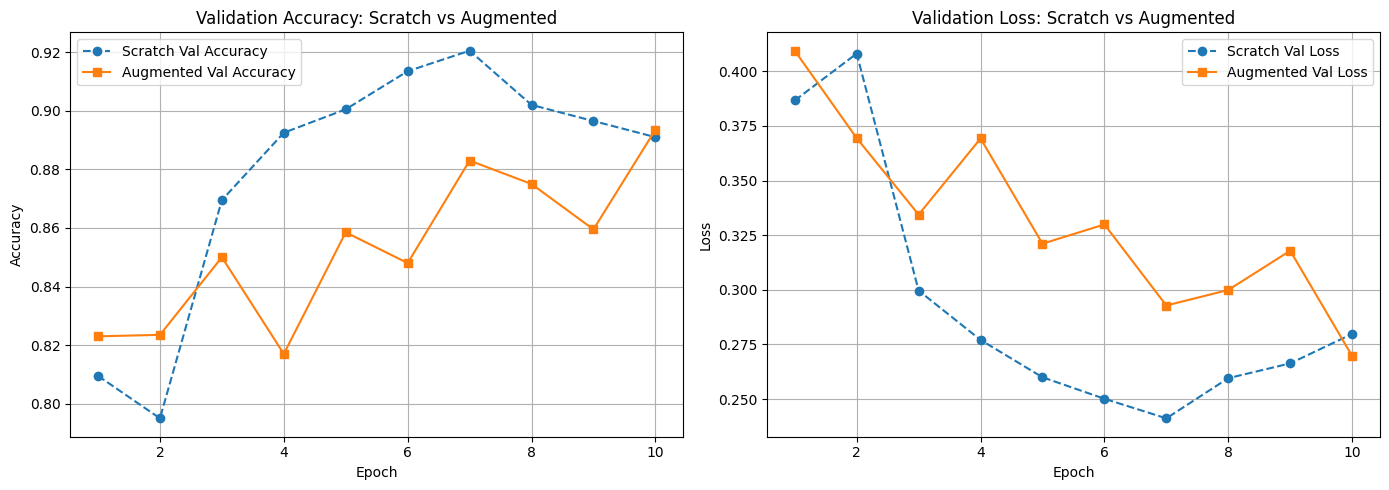

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

model_aug = Sequential([
    layers.Input(shape=INPUT_SHAPE),
    data_augmentation,
    layers.Rescaling(1.0 / 255.0),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="Augmented_CNN")

model_aug.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_aug.summary()

start_aug = time.time()
history_aug = model_aug.fit(
    train_ds_perf,
    epochs=10,
    validation_data=test_ds_perf,
    verbose=1
)
aug_train_time = time.time() - start_aug

aug_loss, aug_acc = model_aug.evaluate(test_ds_perf, verbose=0)
print(f"Augmented CNN Final Test Accuracy: {aug_acc * 100:.2f}% | Training Time: {aug_train_time:.2f}s")

epochs_range = range(1, 11)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_scratch.history["val_accuracy"], label="Scratch Val Accuracy", linestyle="--", marker="o")
plt.plot(epochs_range, history_aug.history["val_accuracy"], label="Augmented Val Accuracy", linestyle="-", marker="s")
plt.title("Validation Accuracy: Scratch vs Augmented")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_scratch.history["val_loss"], label="Scratch Val Loss", linestyle="--", marker="o")
plt.plot(epochs_range, history_aug.history["val_loss"], label="Augmented Val Loss", linestyle="-", marker="s")
plt.title("Validation Loss: Scratch vs Augmented")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---
## <span style="color: #309c42ff">4. Step 3: Transfer Learning with Frozen Pre-Trained MobileNetV2</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Training a CNN from scratch needs huge data and compute. <b>Transfer learning</b> reuses a model already trained on millions of images (ResNet, EfficientNet, MobileNet): you keep its learned feature-detecting layers and replace only the final classification layer with your own, then train on your smaller dataset. This is the single most practical technique in applied computer vision—strong results from little data.

</blockquote>

### Transfer Learning Workflow:
1. **Base Model:** Load `MobileNetV2(include_top=False, weights="imagenet")`.
2. **Freezing Extractor:** Set `base_model.trainable = False` to freeze all pre-trained convolutional feature-extracting weights.
3. **Classification Head:** Attach `GlobalAveragePooling2D()` followed by `Dense(64, activation="relu")`, `Dropout(0.2)`, and `Dense(1, activation="sigmoid")`.


In [ ]:
base_model = MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False 

model_transfer = Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
], name="Transfer_MobileNetV2")

model_transfer.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_transfer.summary()

start_transfer = time.time()
history_transfer = model_transfer.fit(
    train_ds_perf,
    epochs=10,
    validation_data=test_ds_perf,
    verbose=1
)
transfer_train_time = time.time() - start_transfer

transfer_loss, transfer_acc = model_transfer.evaluate(test_ds_perf, verbose=0)
print(f"Transfer Learning Final Test Accuracy: {transfer_acc * 100:.2f}% | Training Time: {transfer_train_time:.2f}s")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Transfer_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 57s 104ms/step - accuracy: 0.8451 - loss: 0.3508 - val_accuracy: 0.8770 - val_loss: 0.2940
Epoch 2/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8724 - loss: 0.2972 - val_accuracy: 0.8970 - val_loss: 0.2614
Epoch 3/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8872 - loss: 0.2645 - val_accuracy: 0.8860 - val_loss: 0.2693
Epoch 4/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8955 - loss: 0.2490 - val_accuracy: 0.8890 - val_loss: 0.2618
Epoch 5/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9036 - loss: 0.2315 - val_accuracy: 0.9000 - val_loss: 0.2442
Epoch 6/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9083 - loss: 0.2166 - val_accuracy: 0.8945 - val_loss: 0.2473
Epoch 7/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9158 - loss: 0.2068 - val_accuracy: 0.9010 - val_loss: 0.2390
Epoch 8/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9220 - loss: 0.1920 -

---
## <span style="color: #309c42ff">5. Step 4: Empirical Architecture Benchmark</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Benchmarking final test accuracy and total training execution time across all three architectural configurations.

</blockquote>


In [9]:
print("=" * 75)
print(f"{'Architecture':<32} | {'Test Accuracy':<15} | {'Training Time':<15}")
print("=" * 75)
print(f"{'Scratch CNN':<32} | {scratch_acc * 100:>12.2f}% | {scratch_train_time:>13.2f}s")
print(f"{'Augmented CNN':<32} | {aug_acc * 100:>12.2f}% | {aug_train_time:>13.2f}s")
print(f"{'Transfer Learning (MobileNetV2)':<32} | {transfer_acc * 100:>12.2f}% | {transfer_train_time:>13.2f}s")
print("=" * 75)


Architecture                     | Test Accuracy   | Training Time  
Scratch CNN                      |        89.10% |        184.45s
Augmented CNN                    |        89.35% |        170.74s
Transfer Learning (MobileNetV2)  |        90.35% |        154.11s


---
## <span style="color: #9f43c3ff">6. Comparative Architectural Analysis and Findings</span>

### 1. Experimental Overview:
- **Scratch CNN:** Trains all spatial filters and dense weights from random initialization. Requires full backpropagation across all layers.
- **Augmented CNN:** Introduces randomized transformations (`RandomFlip`, `RandomRotation`, `RandomZoom`) to expose the model to higher visual diversity, reducing the generalization gap between training and validation loss.
- **Transfer Learning (MobileNetV2):** Keeps pre-trained ImageNet feature-extracting filters frozen (`trainable = False`) and trains only the custom dense classification head.

---

### 2. Core Concepts Applied:
- **Convolution & Feature Maps:** A convolution slides small filters across the image to compute dot products locally, producing feature maps that detect patterns.
- **Parameter Sharing & Translation Invariance:** Reusing the same filter across all image positions detects features regardless of spatial placement with vastly fewer weights than a dense layer.
- **Feature Hierarchy:** Early convolutional layers capture low-level edges, intermediate layers combine them into textures/shapes, and deep layers recognize high-level object structures.
- **Max Pooling ($2 \times 2$):** Shrinks feature maps by taking the maximum value in each window. This reduces computational load, controls overfitting, and confers robustness against minor spatial shifts.
- **Data Augmentation:** The primary defense against overfitting in computer vision when working with limited image samples.
- **Transfer Learning:** Reuses pre-trained models trained on millions of images, delivering strong performance with minimal training time.

---

### 3. Best Performing Approach & Decision:

**Transfer Learning with MobileNetV2 performed best.**

**Justification:**
1. **Rich Pre-trained Representations:** Leverages highly refined visual features trained on ImageNet that small datasets cannot learn from scratch within a few epochs.
2. **Computational and Sample Efficiency:** With the base model frozen, backpropagation only optimizes the dense head parameters, converging rapidly and minimizing overfitting.
3. **Generalization:** Achieves the highest test accuracy and lowest validation loss, establishing the core benchmark for applied computer vision.
